In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hubertsidorowicz/football-players-stats-2026-2027/players_data-2026_2027.csv
/kaggle/input/datasets/hubertsidorowicz/football-players-stats-2026-2027/players_data_light-2026_2027.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
#using a style sheet for matplotlib and seaborn
plt.style.use('ggplot')
#expand the number of columns when a dataframe is displayed
pd.set_option('display.max_columns', 200)

In [3]:
df = pd.read_csv('/kaggle/input/datasets/hubertsidorowicz/football-players-stats-2026-2027/players_data-2026_2027.csv')

In [4]:
#tells us the number of rows and columns (rows, columns)
df.shape

(2034, 102)

In [5]:
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,G+A-PK,Rk_stats_keeper,Nation_stats_keeper,Pos_stats_keeper,Comp_stats_keeper,Age_stats_keeper,Born_stats_keeper,MP_stats_keeper,Starts_stats_keeper,Min_stats_keeper,90s_stats_keeper,GA,GA90,SoTA,Saves,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm,Rk_stats_shooting,Nation_stats_shooting,Pos_stats_shooting,Comp_stats_shooting,Age_stats_shooting,Born_stats_shooting,90s_stats_shooting,Gls_stats_shooting,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK_stats_shooting,PKatt_stats_shooting,Rk_stats_playing_time,Nation_stats_playing_time,Pos_stats_playing_time,Comp_stats_playing_time,Age_stats_playing_time,Born_stats_playing_time,MP_stats_playing_time,Min_stats_playing_time,Mn/MP,Min%,90s_stats_playing_time,Starts_stats_playing_time,Mn/Start,Compl,Subs,Mn/Sub,unSub,PPM,onG,onGA,+/-,+/-90,On-Off,Rk_stats_misc,Nation_stats_misc,Pos_stats_misc,Comp_stats_misc,Age_stats_misc,Born_stats_misc,90s_stats_misc,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000.0,3,2,155,1.7,0,0,0,0,0,0,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,us USA,MF,eng Premier League,25-327,2000.0,1.7,0,1,1,100.0,0.58,0.58,0.0,0.0,0,0,1,us USA,MF,eng Premier League,25-327,2000.0,3,155,52,57.4,1.7,2,63.0,0,1,29.0,0,1.67,0,2,-2,-1.16,-3.51,1,us USA,MF,eng Premier League,25-327,2000.0,1.7,0,0,0,0,5,0,0,0,2,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002.0,2,0,35,0.4,0,0,0,0,0,0,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,ma MAR,FW,es La Liga,24-105,2002.0,0.4,0,3,0,0.0,7.71,0.00,0.0,NaN,0,0,2,ma MAR,FW,es La Liga,24-105,2002.0,2,35,18,7.8,0.4,0,NaN,0,2,18.0,1,0.50,0,1,-1,-2.57,-1.49,2,ma MAR,FW,es La Liga,24-105,2002.0,0.4,0,0,0,1,2,0,6,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004.0,3,3,255,2.8,0,0,0,0,0,0,1,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,ie IRL,DF,it Serie A,22-241,2004.0,2.8,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,3,ie IRL,DF,it Serie A,22-241,2004.0,3,255,85,94.4,2.8,3,85.0,2,0,NaN,0,1.33,5,4,1,0.35,6.35,3,ie IRL,DF,it Serie A,22-241,2004.0,2.8,1,0,0,5,2,0,1,1,5,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006.0,4,0,97,1.1,1,0,1,1,0,0,0,0,0.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,fr FRA,FW,fr Ligue 1,20-162,2006.0,1.1,1,5,2,40.0,4.64,1.86,0.2,0.5,0,0,5,fr FRA,FW,fr Ligue 1,20-162,2006.0,4,97,24,26.9,1.1,0,NaN,0,4,24.0,0,0.75,2,2,0,0.00,0.00,4,fr FRA,FW,fr Ligue 1,20-162,2006.0,1.1,0,0,0,2,2,0,10,0,0,0
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008.0,1,0,5,0.1,0,0,0,0,0,0,0,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,eg EGY,FW,es La Liga,18-256,2008.0,0.1,0,0,0,NaN,0.00,0.00,NaN,NaN,0,0,6,eg EGY,FW,es La Liga,18-256,2008.0,1,5,5,1.1,0.1,0,NaN,0,1,5.0,4,3.00,1,0,1,18.00,14.76,5,eg EGY,FW,es La Liga,18-256,2008.0,0.1,0,0,0,0,1,0,0,0,0,0


In [6]:
#list out all the columns
df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY', 'Fls', 'Fld', 'Off',
       'Crs', 'Int', 'TklW', 'OG'],
      dtype='object', length=102)

In [7]:
#finding out the dtype of a column. edvery column is a seris
df.dtypes

Rk         int64
Player    object
Nation    object
Pos       object
Squad     object
           ...  
Off        int64
Crs        int64
Int        int64
TklW       int64
OG         int64
Length: 102, dtype: object

In [8]:
#the describe button shows us some information about the numeric datasets
df.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,G+A-PK,Rk_stats_keeper,Born_stats_keeper,MP_stats_keeper,Starts_stats_keeper,Min_stats_keeper,90s_stats_keeper,GA,GA90,SoTA,Saves,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm,Rk_stats_shooting,Born_stats_shooting,90s_stats_shooting,Gls_stats_shooting,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,PK_stats_shooting,PKatt_stats_shooting,Rk_stats_playing_time,Born_stats_playing_time,MP_stats_playing_time,Min_stats_playing_time,Mn/MP,Min%,90s_stats_playing_time,Starts_stats_playing_time,Mn/Start,Compl,Subs,Mn/Sub,unSub,PPM,onG,onGA,+/-,+/-90,On-Off,Rk_stats_misc,Born_stats_misc,90s_stats_misc,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
count,2034.000000,2032.000000,2032.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.00000,2034.000000,2034.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,114.000000,114.000000,114.000000,114.000000,115.000000,114.000000,115.000000,115.000000,115.000000,115.000000,2034.000000,2032.000000,2034.000000,2034.000000,2034.000000,2034.000000,1387.000000,2034.000000,2034.000000,1387.000000,846.000000,2034.000000,2034.000000,2034.000000,2032.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,1518.000000,2034.000000,2034.000000,1117.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,1782.000000,2034.000000,2032.000000,2034.000000,2034.00000,2034.000000,2034.000000,2034.000000,2034.000000,2034.000000,2034.00000,2034.000000,2034.000000,2034.000000
mean,1017.500000,25.449803,2000.313484,2.926254,2.044248,183.617011,2.039872,0.271386,0.199115,0.470501,0.255162,0.016224,0.020649,0.32940,0.013274,0.251804,58.000000,1997.208696,3.330435,3.286957,295.826087,3.286957,4.947826,1.557826,15.443478,10.478261,67.254386,1.201754,0.912281,1.201754,0.852174,24.661404,0.365217,0.286957,0.060870,0.017391,1017.500000,2000.313484,2.039872,0.271386,2.577188,0.882006,31.475775,1.581485,0.553176,0.085270,0.286513,0.016224,0.020649,1266.316126,2000.313484,2.926254,183.617011,56.931662,51.821632,2.039872,2.044248,78.721344,1.157817,0.882006,21.199642,0.512291,1.368972,3.071780,3.062930,0.008850,-0.085885,-0.051016,1017.500000,2000.313484,2.039872,0.32940,0.013274,0.002950,2.183382,2.096362,0.351524,3.22468,1.706490,1.815634,0.008358
std,587.309544,4.228859,4.235748,1.231042,1.590060,126.526575,1.406677,0.693656,0.513640,0.933270,0.655136,0.151179,0.176221,0.58313,0.114475,0.924019,33.341666,4.413885,1.219158,1.275719,114.610038,1.273930,2.919515,0.918058,7.450646,5.569887,16.764935,1.122417,0.897996,1.057463,0.900716,27.304279,0.582349,0.525911,0.240137,0.131296,587.309544,4.235748,1.406677,0.693656,3.289924,1.515891,32.609411,3.267227,2.362408,0.184076,0.378235,0.151179,0.176221,730.710783,4.235748,1.231042,126.526575,28.685597,34.546446,1.406677,1.590060,12.375075,1.442169,1.006052,11.882206,0.876594,0.951305,2.902203,2.715566,3.114462,3.679653,5.065328,587.309544,4.235748,1.406677,0.58313,0.114475,0.054246,2.305130,2.414409,0.829741,5.25308,2.252372,2.169622,0.091061
min,1.000000,15.000000,1985.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1986.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1985.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1985.000000,1.000000,1.000000,1.000000,0.200000,0.000000,0.000000,15.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,-90.000000,-91.000000,1.000000,1985.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,509.250000,22.000000,1997.000000,2.0

In [9]:
df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY', 'Fls', 'Fld', 'Off',
       'Crs', 'Int', 'TklW', 'OG'],
      dtype='object', length=102)

In [10]:
#how to drop columns in a datasets 

df = df[['Rk','Player','Nation','Pos','Squad','Comp','Age','Born',
    'MP',#'Starts',
 'Min',
 #'90s',
 'Gls','Ast','G+A',
 #'G-PK','PK','PKatt','CrdY','CrdR','G+A-PK','Rk_stats_keeper','Nation_stats_keeper','Pos_stats_keeper','Comp_stats_keeper', 'Age_stats_keeper',
 #'Born_stats_keeper','MP_stats_keeper','Starts_stats_keeper', 'Min_stats_keeper','90s_stats_keeper','GA','GA90','SoTA', 'Saves','Save%',
# 'W','D', 'L', 'CS','CS%','PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm',
 #'Rk_stats_shooting','Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting','Age_stats_shooting',
 #'Born_stats_shooting', '90s_stats_shooting','Gls_stats_shooting', 'Sh', 'SoT', 'SoT%','Sh/90', 'SoT/90', 'G/Sh','G/SoT',
 #'PK_stats_shooting',
 #'PKatt_stats_shooting',
 #'Rk_stats_playing_time',
 #'Nation_stats_playing_time',
# 'Pos_stats_playing_time',
 #'Comp_stats_playing_time',
 #'Age_stats_playing_time',
 #'Born_stats_playing_time',
# 'MP_stats_playing_time',
# 'Min_stats_playing_time',
 #'Mn/MP',
# 'Min%',
# '90s_stats_playing_time',
 # 'Starts_stats_playing_time',
 # 'Mn/Start',
 # 'Compl',
 # 'Subs',
 # 'Mn/Sub',
 # 'unSub',
 # 'PPM',
 # 'onG',
 # 'onGA',
 # '+/-',
 # '+/-90',
 # 'On-Off',
 # 'Rk_stats_misc',
 # 'Nation_stats_misc',
 # 'Pos_stats_misc',
 # 'Comp_stats_misc',
 # 'Age_stats_misc',
 # 'Born_stats_misc',
 # '90s_stats_misc',
 # 'CrdY_stats_misc',
 # 'CrdR_stats_misc',
 # '2CrdY',
 # 'Fls',
 # 'Fld',
 # 'Off',
 # 'Crs',
 # 'Int',
 # 'TklW', #'OG' 
   ]].copy()

In [11]:
#df.drop(['Comp_stats_shooting', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Age_stats_shooting'], axis=1)

In [12]:
df.shape

(2034, 13)

In [13]:
df.dtypes

Rk          int64
Player     object
Nation     object
Pos        object
Squad      object
Comp       object
Age       float64
Born      float64
MP          int64
Min         int64
Gls         int64
Ast         int64
G+A         int64
dtype: object

In [14]:
df

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Min,Gls,Ast,G+A
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000.0,3,155,0,0,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002.0,2,35,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004.0,3,255,0,0,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006.0,4,97,1,0,1
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008.0,1,5,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2029,2030,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,27.0,1999.0,4,63,0,0,0
2030,2031,Adam Zulevic,sk SVK,FW,Genoa,it Serie A,19.0,2007.0,1,4,0,0,0
2031,2032,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27.0,1998.0,4,306,2,0,2
2032,2033,Leo Østigård,no NOR,DF,Genoa,it Serie A,26.0,1999.0,4,335,0,0,0


In [15]:
df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Min', 'Gls', 'Ast', 'G+A'],
      dtype='object')

In [16]:
df = df.rename(columns={'Rk':'Rank',
                  'Pos':'Position', 'Squad':'Club',
                  'Comp':'League',
                  'Born':'Birth_Date', 'Min':'Minutes',
                  'Gls':'G', 'Ast':'A'})

In [17]:
df.head()

,Rank,Player,Nation,Position,Club,League,Age,Birth_Date,MP,Minutes,G,A,G+A
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000.0,3,155,0,0,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002.0,2,35,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004.0,3,255,0,0,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006.0,4,97,1,0,1
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008.0,1,5,0,0,0


In [18]:
df.isna().sum()

Rank          0
Player        0
Nation        3
Position      0
Club          0
League        0
Age           2
Birth_Date    2
MP            0
Minutes       0
G             0
A             0
G+A           0
dtype: int64

In [19]:
df.dtypes

Rank            int64
Player         object
Nation         object
Position       object
Club           object
League         object
Age           float64
Birth_Date    float64
MP              int64
Minutes         int64
G               int64
A               int64
G+A             int64
dtype: object

In [20]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')


In [21]:
df.head()

,Rank,Player,Nation,Position,Club,League,Age,Birth_Date,MP,Minutes,G,A,G+A
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000.0,3,155,0,0,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002.0,2,35,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004.0,3,255,0,0,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006.0,4,97,1,0,1
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008.0,1,5,0,0,0


In [22]:
df['Birth_Date'] = pd.to_numeric(df['Birth_Date'], errors='coerce')
df['Birth_Date'] = df['Birth_Date'].astype('Int64')

In [23]:
df.head()

,Rank,Player,Nation,Position,Club,League,Age,Birth_Date,MP,Minutes,G,A,G+A
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000,3,155,0,0,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002,2,35,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004,3,255,0,0,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006,4,97,1,0,1
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008,1,5,0,0,0


In [24]:
df.loc[df.duplicated(subset=['Player'])]

,Rank,Player,Nation,Position,Club,League,Age,Birth_Date,MP,Minutes,G,A,G+A
28,29,David Affengruber,at AUT,DF,Fulham,eng Premier League,25.0,2001,1,90,0,0,0
57,58,Mohamed Ali Cho,fr FRA,"FW,MF",Hull City,eng Premier League,22.0,2004,3,48,0,0,0
122,123,Neil El Aynaoui,ma MAR,MF,Roma,it Serie A,25.0,2001,1,12,0,0,0
215,216,Beto,gw GNB,FW,Everton,eng Premier League,28.0,1998,2,33,0,0,0
351,352,Chema,es ESP,MF,Brighton,eng Premier League,21.0,2005,1,26,0,1,1
365,366,Riccardo Ciervo,it ITA,MF,Sassuolo,it Serie A,24.0,2002,1,3,0,0,0
391,392,Félix Correia,pt POR,MF,Lille,fr Ligue 1,25.0,2001,2,94,0,0,0
437,438,Jonathan David,ca CAN,FW,Juventus,it Serie A,26.0,2000,1,56,0,0,0
454,455,Romain Del Castillo,fr FRA,MF,Brest,fr Ligue 1,30.0,1996,2,136,1,0,1
470,471,Boulaye Dia,sn SEN,"FW,MF",Rennes,fr Ligue 1,29.0,1996,2,15,0,0,0


In [25]:
#checking an example duplicate
df.query('Player == "David Affengruber"')

,Rank,Player,Nation,Position,Club,League,Age,Birth_Date,MP,Minutes,G,A,G+A
27,28,David Affengruber,at AUT,DF,Elche,es La Liga,25.0,2001,3,270,0,0,0
28,29,David Affengruber,at AUT,DF,Fulham,eng Premier League,25.0,2001,1,90,0,0,0


In [26]:
df.columns

Index(['Rank', 'Player', 'Nation', 'Position', 'Club', 'League', 'Age',
       'Birth_Date', 'MP', 'Minutes', 'G', 'A', 'G+A'],
      dtype='object')

In [27]:
df = df.loc[~df.duplicated(subset=['Player', 'Nation', 'Club', 'League', 'Birth_Date'])] \
    .reset_index(drop=True).copy()

In [28]:
df

,Rank,Player,Nation,Position,Club,League,Age,Birth_Date,MP,Minutes,G,A,G+A
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000,3,155,0,0,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002,2,35,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004,3,255,0,0,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006,4,97,1,0,1
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008,1,5,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2029,2030,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,27.0,1999,4,63,0,0,0
2030,2031,Adam Zulevic,sk SVK,FW,Genoa,it Serie A,19.0,2007,1,4,0,0,0
2031,2032,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27.0,1998,4,306,2,0,2
2032,2033,Leo Østigård,no NOR,DF,Genoa,it Serie A,26.0,1999,4,335,0,0,0


In [29]:
#Feature Understanding

Text(0, 0.5, 'Numbers of Players with the Age')

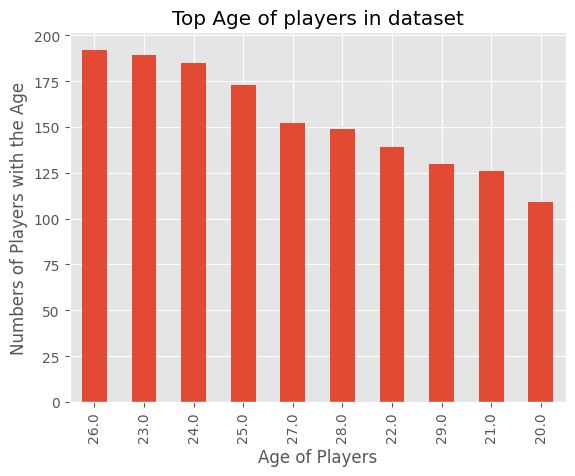

In [30]:
#look for value counts
ax = df['Age'].value_counts() \
    .head(10) \
    .plot(kind='bar', title='Top Age of players in dataset')
ax.set_xlabel('Age of Players')
ax.set_ylabel('Numbers of Players with the Age')

Text(0.5, 0, 'Matches Played')

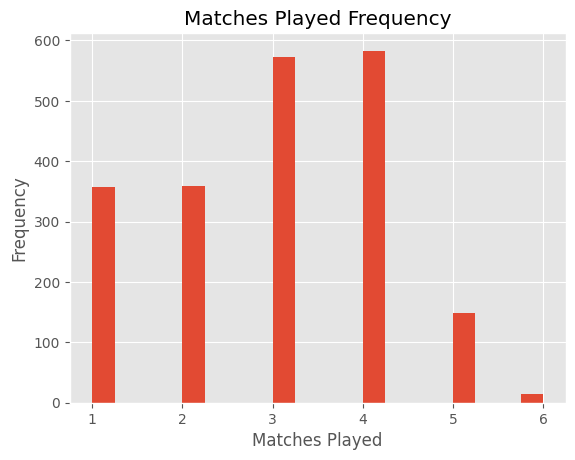

In [31]:
ax = df['MP'].plot(kind='hist', bins=20, title='Matches Played Frequency')
ax.set_xlabel('Matches Played')

Text(0.5, 0, 'Birth Year Curve')

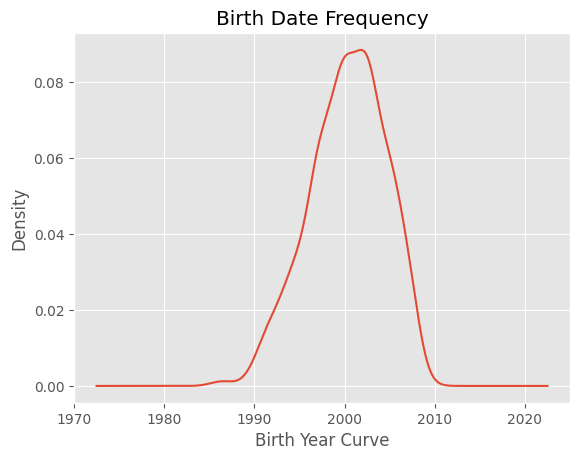

In [32]:
ax = df['Birth_Date'].plot(kind='kde', title='Birth Date Frequency')
ax.set_xlabel('Birth Year Curve')

In [33]:
#Feature Relstionship in datsets

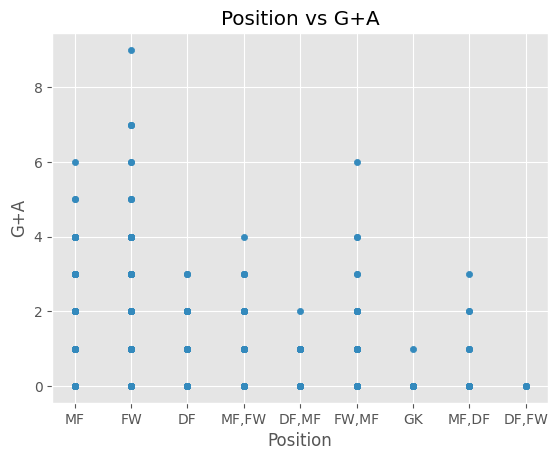

In [34]:
df.plot(kind='scatter',
       x= 'Position',
       y= 'G+A',
       title= 'Position vs G+A')
plt.show()

<Axes: xlabel='Position', ylabel='G+A'>

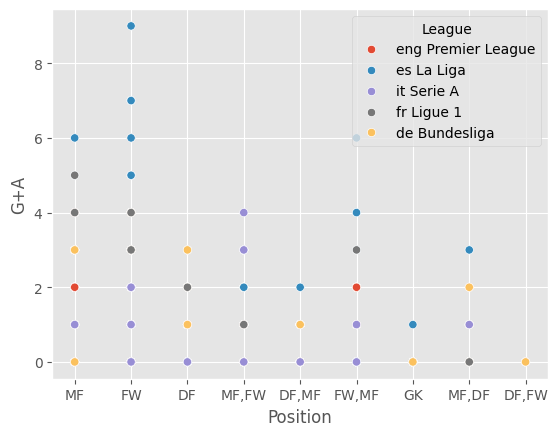

In [35]:
sns.scatterplot(x= 'Position',
       y= 'G+A',
        data= df,
        hue= 'League')

In [36]:
df.head()

,Rank,Player,Nation,Position,Club,League,Age,Birth_Date,MP,Minutes,G,A,G+A
0,1,Brenden Aaronson,us USA,MF,Leeds United,eng Premier League,25.0,2000,3,155,0,0,0
1,2,Haitam Abaida,ma MAR,FW,Málaga,es La Liga,24.0,2002,2,35,0,0,0
2,3,James Abankwah,ie IRL,DF,Udinese,it Serie A,22.0,2004,3,255,0,0,0
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,20.0,2006,4,97,1,0,1
4,5,Hamza Abdelkarim,eg EGY,FW,Barcelona,es La Liga,18.0,2008,1,5,0,0,0


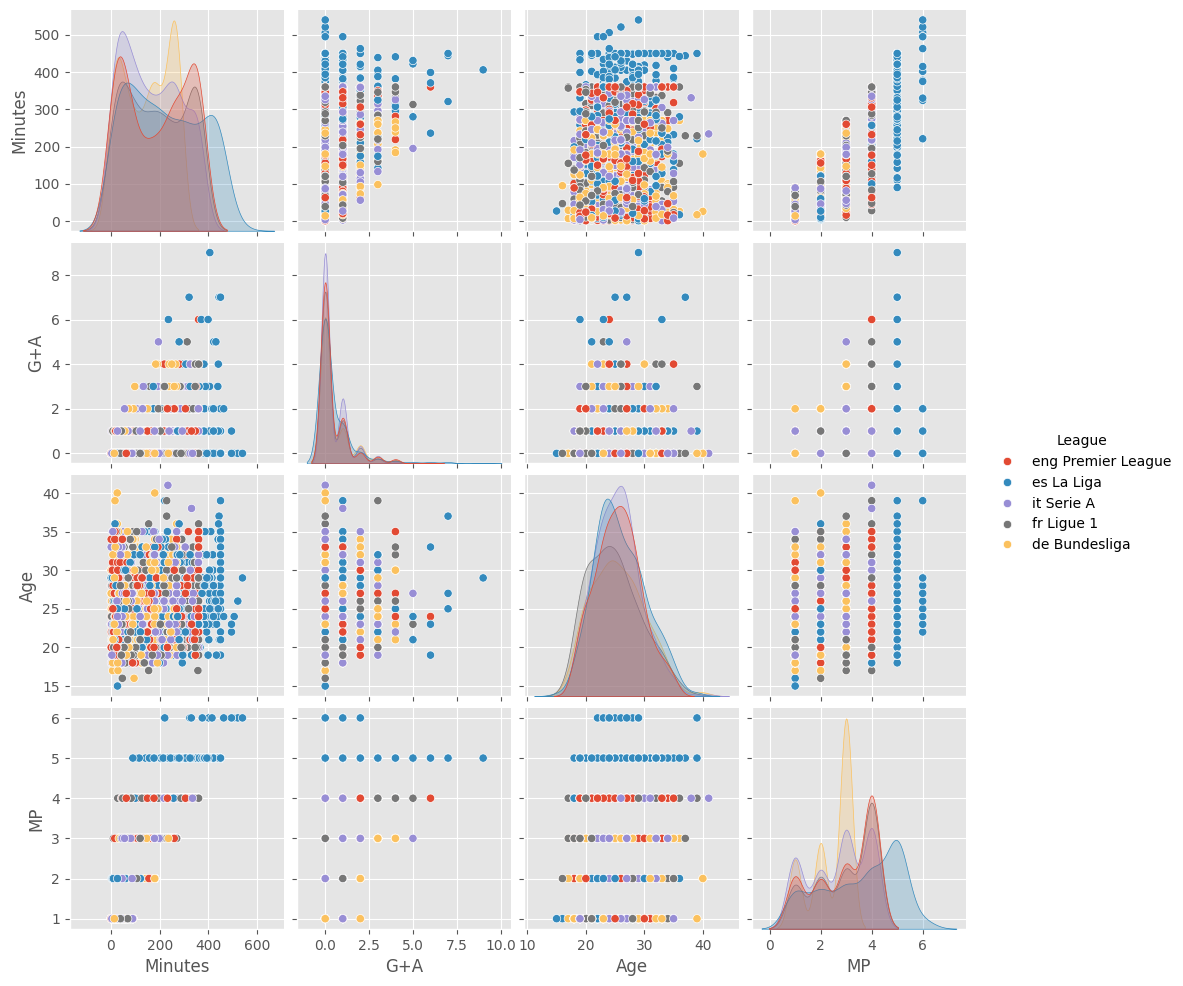

In [37]:
sns.pairplot(df, vars=['Minutes',
                      'G+A', 'Age', 'MP'],
                hue='League')
plt.show()

In [38]:
df_corr = df[['Minutes', 'G+A', 'Age', 'MP']].dropna().corr()
df_corr

,Minutes,G+A,Age,MP
Minutes,1.000000,0.304687,0.184998,0.826235
G+A,0.304687,1.000000,0.035111,0.304239
Age,0.184998,0.035111,1.000000,0.138141
MP,0.826235,0.304239,0.138141,1.000000


<Axes: >

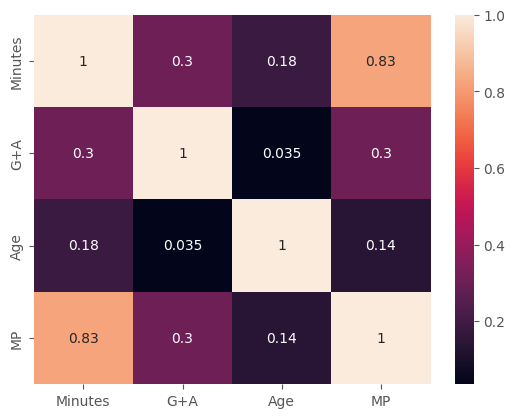

In [39]:
sns.heatmap(df_corr, annot=True)

In [40]:
#Ask a Question about the data
What are the leagues with the better goalscorers?

Object `goalscorers` not found.


Text(0.5, 28.0, 'Average Goals Scored')

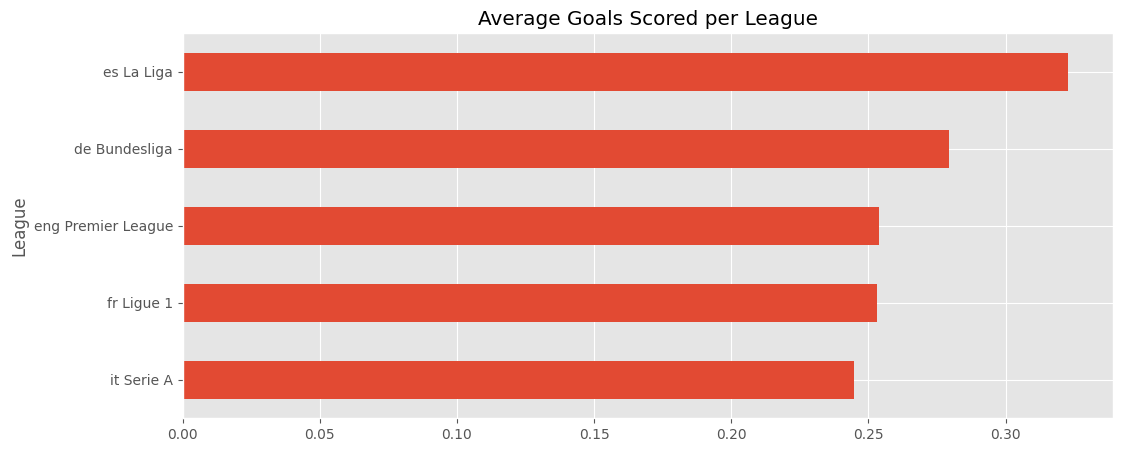

In [41]:
df.query('League != "Other"') \
    .groupby('League')['G'] \
    .agg(['mean', 'count']) \
    .query('count >= 100') \
    .sort_values('mean')['mean'] \
    .plot(kind='barh', figsize=(12, 5), title='Average Goals Scored per League')
ax.set_xlabel('Average Goals Scored')